In [1]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./funlopt/funl_dynamics.jl")
include("./funlopt/funl_utils.jl")
include("./funlopt/funl_constraint.jl")
include("./trajopt/scaling.jl")

compute_scaling (generic function with 1 method)

In [2]:
# load nominal trajectory
using JLD2, FileIO
filename = "./data/traj_result" 
@load filename my_dict
xnom = my_dict["x"]
unom = my_dict["u"]
tnom = my_dict["t"];
N = size(xnom,2) - 1
dtnom = zeros(N)
for i in 1:N
    dtnom[i] = tnom[i+1]-tnom[i]
end

In [3]:
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
push!(c_list, [4.0, 2.5])
push!(H_list, get_H_obs(1.5, 4.0))

vmax = 2.0
vmin = 0.0
wmax = 1.5
wmin = -1.5
list_const = Vector{FunnelConstraint}()
push!(list_const,InputConstraint([1;0],vmax))
push!(list_const,InputConstraint([-1;0],-vmin))
push!(list_const,InputConstraint([0; 1],wmax))
push!(list_const,InputConstraint([0; -1],-wmin))
for i = 1:length(c_list)
    push!(list_const,ObstacleAvoidance(H_list[i],c_list[i]))
end

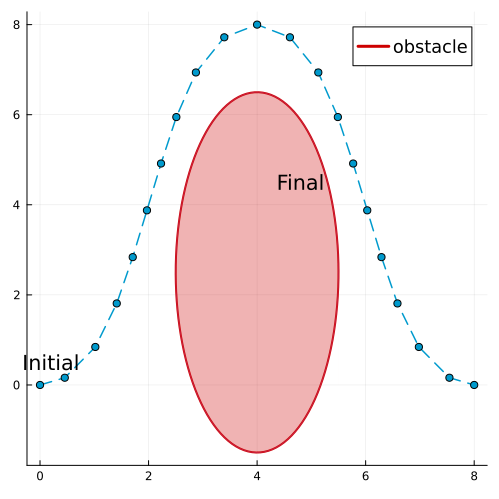

In [4]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
scatter!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linewidth=1.5,label=nothing)
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
annotate!(0.2, 0.5, text("Initial", :black, :center))
annotate!(4.8, 4.5, text("Final", :black, :center))
display(p2)

In [5]:
ix = 3
iu = 2
iw = 2
dynamics = Unicycle()

Unicycle(3, 2, 2, 6, 2, 12, 8, 6, 8, [0.0 0.0 1.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; … ; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 1.0 0.0], 0.03, 0.05, #undef, #undef, #undef, #undef)

In [6]:
A = zeros(ix,ix,N+1)
B = zeros(ix,iu,N+1)
F = zeros(ix,iw,N+1)
for idx in 1:N+1
    A[:,:,idx],B[:,:,idx],F[:,:,idx] = diff_ABF(dynamics,xnom[:,idx],unom[:,idx])
end

In [7]:
Qmax = zeros(ix,ix,N+1)
for idx in 1:N+1
    Qmax[:,:,idx] .= diagm([2^2,2^2,deg2rad(20)^2])
end
Rmax = get_Rmax_unicycle(unom,N,vmax,vmin,wmax,wmin)
;

In [8]:
include("./funlopt/funl_utils.jl")

propagate_from_funnel_entry (generic function with 2 methods)

In [9]:
gamma_est = Lipschitz_estimation_around_traj(N,100,xnom,unom,dynamics,Qmax,Rmax)
gamma = gamma_est[1:N];

In [10]:
gamma = gamma

20-element Vector{Any}:
 [0.049512487347223154 0.0; 0.0 0.1518878013287842]
 [0.18232567281673942 0.0; 0.0 0.2227176735890423]
 [0.22258149953679887 0.0; 0.0 0.19466091611863476]
 [0.21530119261878986 0.0; 0.0 0.17808620552976864]
 [0.2116096015329042 0.0; 0.0 0.17146163063098013]
 [0.19709047529306203 0.0; 0.0 0.1700720457709061]
 [0.19774695381479312 0.0; 0.0 0.17080713602724357]
 [0.20106475401277793 0.0; 0.0 0.1745754104599134]
 [0.20219104954957404 0.0; 0.0 0.18412382013481232]
 [0.18147526475139747 0.0; 0.0 0.17079843788785187]
 [0.08282253081513923 0.0; 0.0 0.16770105802284593]
 [0.20781892516843242 0.0; 0.0 0.1385909917397213]
 [0.22166439453457457 0.0; 0.0 0.11886465818478666]
 [0.21313552348134548 0.0; 0.0 0.1386653214173515]
 [0.20993827288514588 0.0; 0.0 0.10668374729752239]
 [0.20930212906833326 0.0; 0.0 0.10635713074444701]
 [0.17312974543615872 0.0; 0.0 0.14377184714551636]
 [0.18758381844833358 0.0; 0.0 0.1410253227631825]
 [0.19841629221245846 0.0; 0.0 0.14457950508052

# Estimation of $\beta$

In [11]:
using Interpolations

In [12]:
u_fit = [LinearInterpolation(tnom, unom[idx,:],extrapolation_bc=Flat()) for idx in 1:iu]
A_fit = [[LinearInterpolation(tnom, A[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
B_fit = [[LinearInterpolation(tnom, B[i,j,:], extrapolation_bc=Flat()) for j in 1:iu] for i in 1:ix ]
F_fit = [[LinearInterpolation(tnom, F[i,j,:], extrapolation_bc=Flat()) for j in 1:iw] for i in 1:ix ];

In [13]:
function model_wrapper!(f,x,p,t)
    um = p[1]
    up = p[2]
    dt = p[3]
    alpha = (dt - t) / dt
    beta = t / dt
    u1 = alpha*um + beta*up
    f .= forward(dynamics,x,u1)
end

model_wrapper! (generic function with 1 method)

In [14]:
N_sampling = 20
beta = []
beta_vec = []
for i = 1:N
    tspan = (0,tnom[i+1]-tnom[i])
    saveat = range(0, stop=tnom[i+1]-tnom[i], length=N_sampling)
    prob = ODEProblem(model_wrapper!,xnom[:,i],tspan,(unom[:,i],unom[:,i+1],tnom[i+1]-tnom[i]),saveat = saveat)
    sol = solve(prob, Tsit5(), reltol=1e-9, abstol=1e-9;verbose=false);
    @assert(isapprox(sol.u[end],xnom[:,i+1];atol=0.0001))
    delta = []
    delta_vec = zeros(N_sampling,6)
    for idx_sample = 1:N_sampling
        t_eval = sol.t[idx_sample] + tnom[i]
        x_eval = sol.u[idx_sample]
        u_eval = get_u_interp(t_eval,u_fit)
        A_eval,B_eval,F_eval = diff_ABF(dynamics,x_eval,u_eval)
        eA = get_ABF_interp(t_eval,A_fit,ix,ix) .- A_eval
        eB = get_ABF_interp(t_eval,B_fit,ix,iu) .- B_eval
        eF = get_ABF_interp(t_eval,F_fit,ix,iw) .- F_eval

        delta_ = [eA eB eF]
        push!(delta,opnorm(delta_,2))
        delta_vec[idx_sample,:] .= [abs(eA[1,3]), abs(eA[2,3]), abs(eB[1,1]), abs(eB[2,1]), abs(eF[1,1]), abs(eF[2,1])]
    end
    # push!(beta,maximum(delta))
    push!(beta,diagm(maximum(delta_vec,dims=1)[1,:]))
end

In [15]:
C1 = [0 0 1;0 0 1;0 0 0;0 0 0;0 0 0;0 0 0]
D1 = [0 0;0 0;1 0;1 0;0 0;0 0]
G1 = [0 0;0 0;0 0;0 0;1 0;1 0]
E1 = [1 0 1 0 1 0;0 1 0 1 0 1;0 0 0 0 0 0]

dynamics.C = [C1;dynamics.Co]
dynamics.D = [D1;dynamics.Do]
dynamics.E = [E1 dynamics.Eo]
dynamics.G = [G1;dynamics.Go];

In [16]:
xmin = [0;0;0];
xmax = [1;1;pi];
umin = [0;0];
umax = [1;1];
scaler = Scaling(xmin, xmax, umin, umax, 1e3 * Matrix{Float64}(1.0I,dynamics.ilam,dynamics.ilam),tnom[end],0,0)

Scaling([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 3.141592653589793], [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [1.0 0.0; 0.0 1.0], [1.0 0.0; 0.0 1.0], [0.0, 0.0], [1000.0 0.0 … 0.0 0.0; 0.0 1000.0 … 0.0 0.0; … ; 0.0 0.0 … 1000.0 0.0; 0.0 0.0 … 0.0 1000.0], 1.0, 0.0, 0.0)

In [17]:
include("./funlopt/funl_synthesis.jl")

run! (generic function with 3 methods)

In [18]:
function linesearch_and_solve(list_lambda_w,flag_copositivity_type)
    list_solve_time = []
    cost_lambda_w = []
    list_fs = []
    println("Line search for lambda_w from 0.01 to 2.0")
    for lambda_w in list_lambda_w
            fs = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=flag_copositivity_type)
            cost,solve_time = run!(fs,
            gamma,
            beta,
            xnom,unom,tnom,"Mosek",Qmax,Rmax)
            println("lambda_w: ",lambda_w, " cost: ",abs(cost) < 1e-6 ? "diverged" : cost)
            push!(cost_lambda_w,cost)
            push!(list_fs,fs)
            push!(list_solve_time,solve_time)
    end
    return list_fs,cost_lambda_w,list_solve_time
end
function get_optimal_solution(list_lambda_w,list_fs,cost_lambda_w,list_solve_time)
    idx_lambda_w = 1:length(list_lambda_w)
    idx_converged = abs.(cost_lambda_w) .>= 1e-6
    cost_lambda_w_converged = cost_lambda_w[idx_converged]
    idx_fs = argmin(cost_lambda_w_converged)
    idx_min = idx_lambda_w[idx_converged][idx_fs]

    lambda_w = list_lambda_w[idx_min]
    cost = cost_lambda_w[idx_min]
    fs = list_fs[idx_min]
    solve_time = list_solve_time[idx_min]

    println(lambda_w," is picked. The corresponding cost is ",cost,". The solve time is ",solve_time,".")
    return fs
end

get_optimal_solution (generic function with 1 method)

In [19]:
list_lambda_w = [i for i in range(0.1,stop=0.5,length=11)]

11-element Vector{Float64}:
 0.1
 0.14
 0.18
 0.22
 0.26
 0.3
 0.34
 0.38
 0.42
 0.46
 0.5

In [20]:
list_fs1,cost_lambda_w1,list_solve_time1 = linesearch_and_solve(list_lambda_w,1)
fs1 = get_optimal_solution(list_lambda_w,list_fs1,cost_lambda_w1,list_solve_time1)

Line search for lambda_w from 0.01 to 2.0
lambda_w: 0.1 cost: diverged
lambda_w: 0.14 cost: diverged
lambda_w: 0.18 cost: 7.824081673572681
lambda_w: 0.22 cost: -3.4237231203553784
lambda_w: 0.26 cost: -3.5990855503991064
lambda_w: 0.3 cost: -3.4099583373292925
lambda_w: 0.34 cost: -3.0761102973451155
lambda_w: 0.38 cost: -2.7378542434897652
lambda_w: 0.42 cost: -2.4273142447093004
lambda_w: 0.46 cost: -2.1521909682465896
lambda_w: 0.5 cost: -1.9115783078205761
0.26 is picked. The corresponding cost is -3.5990855503991064. The solve time is 1.5870349407196045.


FunnelSynthesis(Unicycle(3, 2, 2, 6, 2, 12, 8, 6, 8, [0.0 0.0 1.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; … ; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 1.0 0.0], 0.03, 0.05, [0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 1.0 0.0; 0.0 0.0], [1.0 0.0 … 1.0 0.0; 0.0 1.0 … 0.0 1.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 1.0 0.0]), FunnelConstraint[InputConstraint([1, 0], 2.0), InputConstraint([-1, 0], -0.0), InputConstraint([0, 1], 1.5), InputConstraint([0, -1], 1.5), ObstacleAvoidance([0.6666666666666666 0.0; 0.0 0.25], [4.0, 2.5])], Scaling([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 3.141592653589793], [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [1.0 0.0; 0.0 1.0], [1.0 0.0; 0.0 1.0], [0.0, 0.0], [1000.0 0.0 … 0.0 0.0; 0.0 1000.0 … 0.0 0.0; … ; 0.0 0.0 … 1000.0 0.0; 0.0 0.0 … 0.0 1000.0], 1.0, 0.0, 0.0), FunnelSolution([1.3357153358635176 1.177978531660913 0.1

In [21]:
list_fs2,cost_lambda_w2,list_solve_time2 = linesearch_and_solve(list_lambda_w,2)
fs2 = get_optimal_solution(list_lambda_w,list_fs2,cost_lambda_w2,list_solve_time2)

Line search for lambda_w from 0.01 to 2.0
lambda_w: 0.1 cost: diverged
lambda_w: 0.14 cost: 7.56577703612827
lambda_w: 0.18 cost: 7.837546816399874
lambda_w: 0.22 cost: -3.4801272070836267
lambda_w: 0.26 cost: -3.652017516391571
lambda_w: 0.3 cost: -3.474681399579327
lambda_w: 0.34 cost: -3.135278494454259
lambda_w: 0.38 cost: -2.7901611570268825
lambda_w: 0.42 cost: -2.47466115599222
lambda_w: 0.46 cost: -2.1958812227649345
lambda_w: 0.5 cost: -1.9518710317764254
0.26 is picked. The corresponding cost is -3.652017516391571. The solve time is 12.534188032150269.


FunnelSynthesis(Unicycle(3, 2, 2, 6, 2, 12, 8, 6, 8, [0.0 0.0 1.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; … ; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 1.0 0.0], 0.03, 0.05, [0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 1.0 0.0; 0.0 0.0], [1.0 0.0 … 1.0 0.0; 0.0 1.0 … 0.0 1.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 1.0 0.0]), FunnelConstraint[InputConstraint([1, 0], 2.0), InputConstraint([-1, 0], -0.0), InputConstraint([0, 1], 1.5), InputConstraint([0, -1], 1.5), ObstacleAvoidance([0.6666666666666666 0.0; 0.0 0.25], [4.0, 2.5])], Scaling([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 3.141592653589793], [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [1.0 0.0; 0.0 1.0], [1.0 0.0; 0.0 1.0], [0.0, 0.0], [1000.0 0.0 … 0.0 0.0; 0.0 1000.0 … 0.0 0.0; … ; 0.0 0.0 … 1000.0 0.0; 0.0 0.0 … 0.0 1000.0], 1.0, 0.0, 0.0), FunnelSolution([1.3672172057198573 1.1498053123912366 0.

In [22]:
lambda_w = 0.26
fsm1 = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=-1)
cost,solve_time = run!(fsm1,
gamma,
beta,
xnom,unom,tnom,"Mosek",Qmax,Rmax)
println("lambda_w: ",lambda_w, " cost: ",cost," solve time ",solve_time)

lambda_w: 0.26 cost: -4.786843704015458 solve time 0.49631810188293457


In [23]:
fs0 = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=0)
cost,solve_time = run!(fs0,
gamma,
beta,
xnom,unom,tnom,"Mosek",Qmax,Rmax)
println("lambda_w: ",lambda_w, " cost: ",cost," solve time ",solve_time)

lambda_w: 0.26 cost: -3.6896015490691987 solve time 1.132706880569458


In [24]:
Qnom_m1,Ynom_m1,lamnom_m1 = fsm1.solution.Q,fsm1.solution.Y,fsm1.solution.lam
Qnom0,Ynom0,lamnom0 = fs0.solution.Q,fs0.solution.Y,fs0.solution.lam
Qnom1,Ynom1,lamnom1 = fs1.solution.Q,fs1.solution.Y,fs1.solution.lam
Qnom,Ynom,lamnom = fs2.solution.Q,fs2.solution.Y,fs2.solution.lam

([1.3672172057198573 1.1498053123912366 0.1454724689411386; 1.1498053123912366 2.8288927520196485 -0.17441606152798864; 0.1454724689411386 -0.17441606152798864 0.0954286507615009;;; 1.24270902482521 1.2089016301718782 0.23588459837144202; 1.2089016301718782 3.4699680279596685 -0.10342178984474236; 0.23588459837144202 -0.10342178984474236 0.10166630752711767;;; 0.9085975493193902 0.9038884368834879 0.24441268595725985; 0.9038884368834879 3.735711381518809 -0.07146343679879677; 0.24441268595725985 -0.07146343679879677 0.10252269503906165;;; … ;;; 0.1846720310722524 0.005820404040899888 -0.1193564959515003; 0.005820404040899888 0.13965216011999623 -0.06764854144718391; -0.1193564959515003 -0.06764854144718391 0.11692066170620057;;; 0.17583493482597126 0.0889446060953572 -0.11053331940447589; 0.0889446060953572 0.12801315588533815 -0.08335248170720085; -0.11053331940447589 -0.08335248170720085 0.11608071850773585;;; 0.24960140132081415 0.08456454826430129 -0.05755545848253009; 0.0845645482

In [25]:
# Set default plot settings for academic paper
default(fontfamily="Times",  # Use Times New Roman font
        titlefont=14,        # Title font size
        guidefont=12,        # Label (guide) font size
        tickfont=10,         # Tick font size
        legendfont=12,       # Legend font size
        grid=true)          # Remove grid lines for a cleaner look


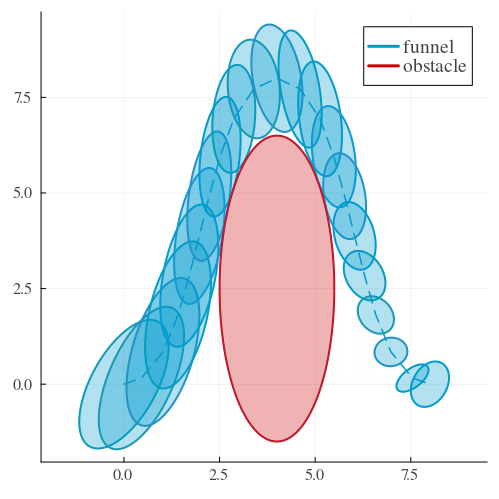

In [26]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    # plot_ellipse(p2,Qnom_[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=true,idx1=1,idx2=2)
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",label=label,idx1=1,idx2=2)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
display(p2)

In [27]:
input_proj_funl_node,Rnom = project_onto_input(Qnom,Ynom)

(Any[Any[0.28726482765091094, 0.8706809450644417, 0.6360157391925657, 0.5765373093265379, 0.5713172578745286, 0.5714913013321039, 0.5721068847973874, 0.5758464431775174, 0.6122605937160335, 0.8661898156826301  …  0.866131488470657, 0.6122486280452731, 0.5758415216656096, 0.5721012852038758, 0.5714870690104549, 0.5713127416257943, 0.576534060331401, 0.6360132625235116, 0.9802967224663609, 0.2872737494456056], Any[0.8256508175894454, 0.5744776690994557, 1.132125024474726, 1.38181877000307, 1.4660758925606256, 1.4972463152150657, 1.476111959433044, 1.4116203252935344, 1.2174188151321998, 0.7393051714691439  …  0.7392262100110651, 1.217338120408757, 1.4115286585594164, 1.4752763472953936, 1.4962060979251233, 1.4655582638413402, 1.3819176531965855, 1.13224487840653, 0.5862102658336292, 0.8261594243803897]], [0.08252108120530757 -3.9008800228576284e-5; -3.900880022859515e-5 0.6816992725861196;;; 0.7580853080983093 -0.052539530291452946; -0.05253953029145268 0.33002459229394376;;; 0.404516020

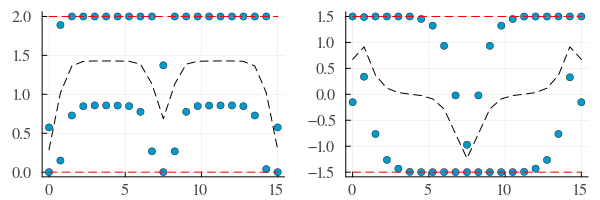

In [28]:
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[1,:]+input_proj_funl_node[1],color="deepskyblue3",label="")
scatter!(tnom,unom[1,:]-input_proj_funl_node[1],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[2,:]+input_proj_funl_node[2],color="deepskyblue3",label="")
scatter!(tnom,unom[2,:]-input_proj_funl_node[2],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
plot(p1,p2,layout=(1,2),size=(600,200))

# samples

In [ ]:
Q_fit = [[LinearInterpolation(tnom, Qnom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
Y_fit = [[LinearInterpolation(tnom, Ynom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:iu ]
;

In [ ]:
include("./funlopt/funl_utils.jl")

In [ ]:
num_sample = 500
xs_list = []
for i in 1:num_sample
    z = randn(ix)
    z = z / norm(z)
    push!(xs_list,xnom[:,1] + sqrt(Qnom[:,:,1]) * z)
end

In [ ]:
xsam_fwd,tsam,xsam,usam,xnomprop = [],[],[],[],[]
i = 0
for xs in xs_list
    # println(i)
    i += 1
    xf_,ts_,xsam_,usam_,xnom_ = propagate_from_funnel_entry_uncertain_dynamics(xs,
        dynamics,
        xnom,unom,tnom,
        Qnom,Ynom)
    push!(xsam_fwd,xf_)
    push!(tsam,ts_)
    push!(xsam,xsam_)
    push!(usam,usam_)
    push!(xnomprop,xnom_)
end

In [ ]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",label=label)
end
# plot_ellipse(p2,fs.solution.Qi,xnom[:,1],"green3",label="initial and final")
# plot_ellipse(p2,fs.solution.Qf,xnom[:,end],"green3")
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
for x_ in xsam
    plot!(x_[1,:],x_[2,:],color="purple",label=nothing)
end
display(p2)

In [ ]:
# Lyapunov function
Lypsam = []
idx = 1
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    xprop_ = xnomprop[idx]
    Lyp = []
    for iode in 1:length(tsam_)
        t_ = tsam_[iode]
        x_ = xsam_[:,iode]
        xnom_ = xprop_[:,iode]
        Q_ = get_ABF_interp(t_,Q_fit,ix,ix)
        val = (x_ - xnom_)' * inv(Q_) * (x_ - xnom_)
        push!(Lyp,val)
    end
    push!(Lypsam,Lyp)
end


In [ ]:
p3 = Plots.plot(; size=(500,300))
for idx = 1:length(tsam)
    plot!(tsam[idx],Lypsam[idx],c=:purple,label="")
end
plot!(tsam[1],tsam[1]*0 .+ 1.0,c=:red,linestyle=:dash,label="")
ylims!(p3, 0.0, 1.5)
display(p3)

In [ ]:
p1 = plot(tsam[1],xnomprop[1][1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[1,:] + sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[1,:] - sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[1,:],color="purple",label="")
end
p2 = plot(tsam[1],xnomprop[1][2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[2,:] + sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[2,:] - sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[2,:],color="purple",label="")
end
p3 = plot(tsam[1],xnomprop[1][3,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[3,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[3,:] + sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[3,:] - sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[3,:],color="purple",label="")
end
plot(p1,p2,p3,layout=(3,1),size=(600,400))

In [ ]:
length_idx = length(tsam)
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[1,:]+input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[1,:]-input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[1,:],color="purple",label="")
end
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[2,:]+input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[2,:]-input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[2,:],color="purple",label="")
end
plot(p1,p2,layout=(1,2),size=(800,400))

In [29]:
funl_dict = Dict(
                "beta" => beta, "gamma" => gamma,
                "Q_m1" => Qnom_m1, "Y_m1" => Ynom_m1, "lam_m1" => lamnom_m1,
                "Q0" => Qnom0, "Y0" => Ynom0, "lam0" => lamnom0,
                "list_lambda_w" => list_lambda_w,
                "Q1" => Qnom1, "Y1" => Ynom1, "lam1" => lamnom1,
                "cost_lambda_w1" => cost_lambda_w1, "list_solve_time1" => list_solve_time1,
                "Q2" => Qnom, "Y2" => Ynom, "lam2" => lamnom,
                "cost_lambda_w2" => cost_lambda_w2, "list_solve_time2" => list_solve_time2,
                )

using JLD2, FileIO
@save "./data/funnel_result_unicycle" funl_dict